# Patient Recovery Time Prediction - Machine Learning Pipeline


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings

sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')


## 1. Select a dataset and define the practical business problem
### Practical Business Problem
Predicting patient recovery time is crucial for hospital bed allocation and resource management. Instead of predicting the exact number of days (which is biologically highly variable), we frame this as a **Classification Problem**:
- **Class 0 (Fast/Normal Recovery):** Recovery in <= 7 days.
- **Class 1 (Prolonged Recovery):** Recovery in > 7 days.

This allows the hospital to reliably identify patients at high risk of extended stays and prioritize care.

### Research Questions
1. **RQ1:** How do patient baseline demographics (Age, Sex) and physiological vital signs (SPO2, Body Temperature, Blood Pressure) correlate with prolonged recovery?
2. **RQ2:** Are specific medical diagnoses strongly associated with a higher probability of prolonged recovery (> 7 days)?


## 2. Exploratory Data Analysis (EDA)


In [2]:
# Load Dataset
df = pd.read_excel('Patient_Recovery_Time.xlsx')
df.columns = df.columns.str.strip()
df.rename(columns={'ReCovery Time': 'Recovery Time', 'Diagnose': 'Diagnosis'}, inplace=True)


### a. Understand the Dataset


#### i. Check dataset shape (rows x columns)


In [3]:
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")


Dataset Shape: 2000 rows x 9 columns


#### ii. Preview of the Data


In [4]:
print("1. df.head()")
display(df.head())
print("\n2. df.tail()")
display(df.tail())
print("\n3. info()")
df.info()


1. df.head()


,Age,Sex,Diagnosis,Systolic_BP,Diastolic_BP,SPO2,Body Temperature,ICU Admission,Recovery Time
0,65,Female,Pregnancy & Obstetrics,120,70,99,36.0,No,6.0
1,10,Female,Trauma,120,80,99,36.0,No,1.0
2,13,Male,Hypertension,110,70,100,36.1,No,1.0
3,26,Female,Gastrointestinal Disease,118,67,98,36.5,No,2.0
4,7,Male,Trauma,106,75,99,36.0,No,1.0



2. df.tail()


,Age,Sex,Diagnosis,Systolic_BP,Diastolic_BP,SPO2,Body Temperature,ICU Admission,Recovery Time
1995,44,Male,Cancer,120,80,97,36.9,No,6.0
1996,39,Male,Cancer,122,78,98,36.7,No,8.0
1997,50,Female,Urinary Disease,118,76,97,36.6,No,9.0
1998,61,Male,Cardiovascular Disease,150,92,87,37.9,Yes,18.0
1999,52,Male,Hypertension,155,95,85,39.0,Yes,20.0



3. info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2000 non-null   int64  
 1   Sex               2000 non-null   object 
 2   Diagnosis         2000 non-null   object 
 3   Systolic_BP       2000 non-null   int64  
 4   Diastolic_BP      2000 non-null   int64  
 5   SPO2              2000 non-null   int64  
 6   Body Temperature  2000 non-null   float64
 7   ICU Admission     2000 non-null   object 
 8   Recovery Time     1998 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 140.8+ KB


### b. Check Data Types and Structure


In [5]:
print(df.dtypes)


Age                   int64
Sex                  object
Diagnosis            object
Systolic_BP           int64
Diastolic_BP          int64
SPO2                  int64
Body Temperature    float64
ICU Admission        object
Recovery Time       float64
dtype: object


### c. Identify data types (numerical, categorical, text, datetime)


Based on the dataset:
- **Numerical:** Age, SPO2, Body Temperature, Systolic_BP, Diastolic_BP, Recovery Time
- **Categorical (Text):** Sex, Diagnosis, ICU Admission
- **Datetime:** Not applicable (Dataset does not contain date/time fields).


### d. Descriptive Statistics


In [6]:
# First, we need to clean raw text formats so we can compute stats
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Sex'] = df['Sex'].astype(str).str.strip().str.title()
df['SPO2'] = pd.to_numeric(df['SPO2'], errors='coerce')
df['Body Temperature'] = pd.to_numeric(df['Body Temperature'], errors='coerce')
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'], errors='coerce')
df['ICU Admission'] = df['ICU Admission'].astype(str).str.strip().str.title()

num_cols = ['Age', 'SPO2', 'Body Temperature', 'Systolic_BP', 'Diastolic_BP', 'Recovery Time']
cat_cols = ['Sex', 'Diagnosis', 'ICU Admission']


#### i. Mean, median, mode, std, min, max for numerical features


In [7]:
desc_stats = df[num_cols].describe().T
desc_stats['mode'] = df[num_cols].mode().iloc[0]
display(desc_stats[['mean', '50%', 'mode', 'std', 'min', 'max']].rename(columns={'50%':'median'}))


,mean,median,mode,std,min,max
Age,40.291000,33.0,30.0,21.737538,1.0,103.0
SPO2,97.653000,98.0,99.0,2.719244,70.0,100.0
Body Temperature,36.647765,36.3,36.0,10.417979,3.5,369.1
Systolic_BP,120.022000,118.0,118.0,19.545371,13.0,224.0
Diastolic_BP,74.281000,74.0,78.0,23.850062,0.0,1001.0
Recovery Time,3.799299,2.0,1.0,4.434722,1.0,68.0


#### ii. Value counts for categorical features


In [8]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")


--- Sex ---
Sex
Female    1308
Male       692
Name: count, dtype: int64 

--- Diagnosis ---
Diagnosis
Cancer                      147
Kidney Disease              145
Hypertension                143
Urinary Disease             142
Infectious Disease          136
Orthopedic Injury           136
Neurological Disease        135
Diabetes                    132
Other                       132
Respiratory Disease         131
Cardiovascular Disease      127
Gastrointestinal Disease    125
Emergency Condition         125
Pregnancy & Obstetrics      122
Trauma                      122
Name: count, dtype: int64 

--- ICU Admission ---
ICU Admission
No     1866
Yes     134
Name: count, dtype: int64 



#### iii. Skewness & kurtosis to understand distribution


In [9]:
for col in num_cols:
    print(f"{col:<17} | Skewness: {skew(df[col].dropna()):6.2f} | Kurtosis: {kurtosis(df[col].dropna()):6.2f}")


Age               | Skewness:   0.65 | Kurtosis:  -0.52
SPO2              | Skewness:  -4.35 | Kurtosis:  25.55
Body Temperature  | Skewness:  31.21 | Kurtosis: 980.56
Systolic_BP       | Skewness:   0.69 | Kurtosis:   3.68
Diastolic_BP      | Skewness:  29.32 | Kurtosis: 1138.24
Recovery Time     | Skewness:   4.91 | Kurtosis:  44.85


### e. Data Distribution Visualization


#### i. Histograms for distribution


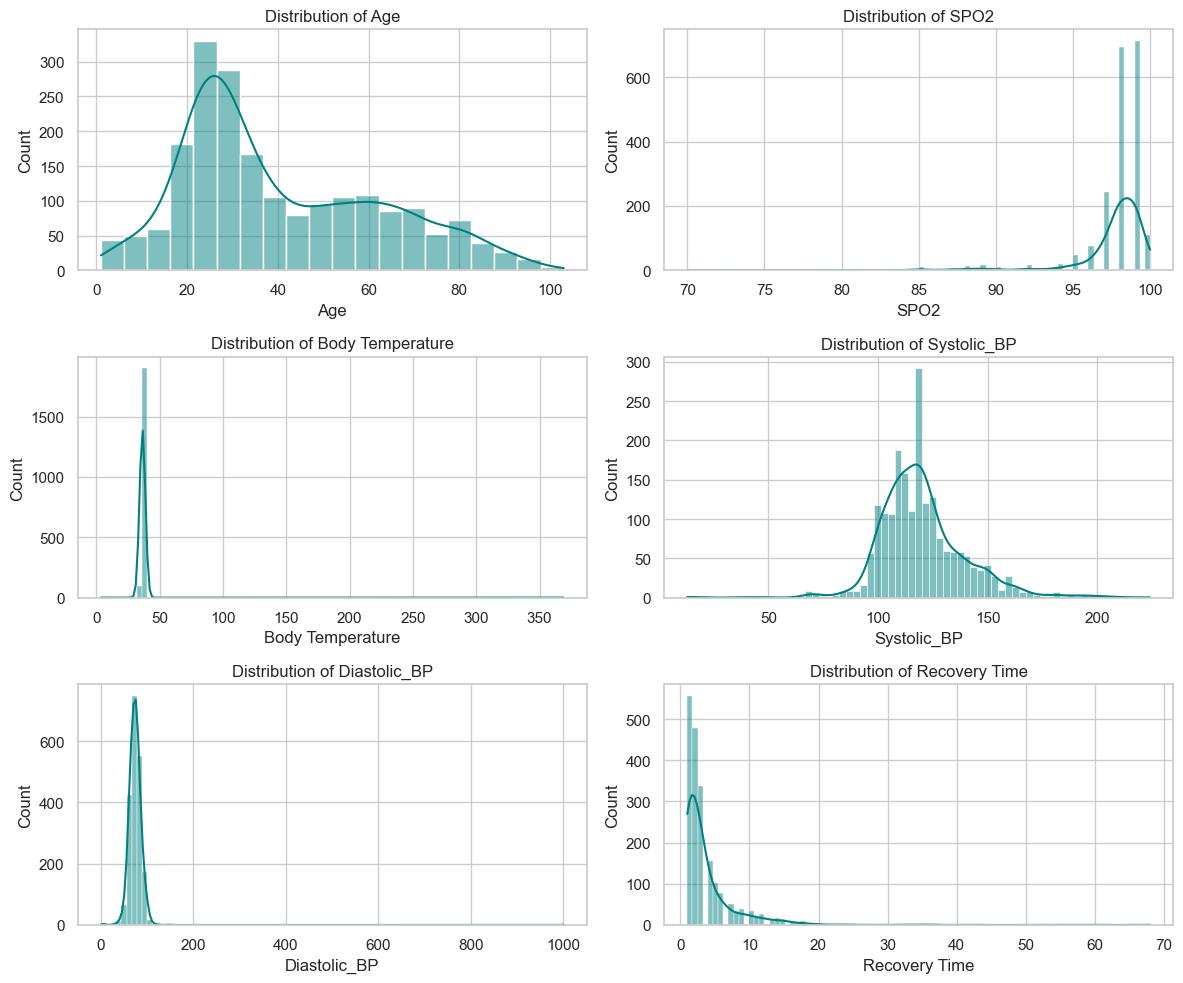

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


#### ii. Categorical Data Analysis & iii. Count plots / bar plots for categorical features


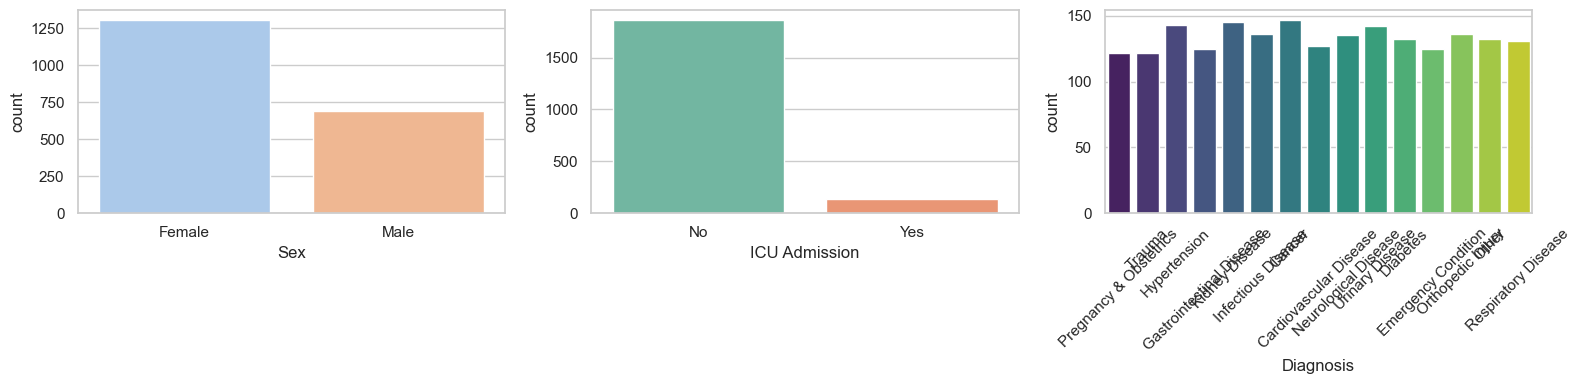

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x='Sex', ax=axes[0], palette='pastel')
sns.countplot(data=df, x='ICU Admission', ax=axes[1], palette='Set2')
sns.countplot(data=df, x='Diagnosis', ax=axes[2], palette='viridis')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


#### iv. Grouped summaries (e.g., mean target by category)


In [12]:
print("Mean Recovery Time by Diagnosis:")
display(df.groupby('Diagnosis')['Recovery Time'].mean().sort_values(ascending=False))
print("\nMean Recovery Time by ICU Admission:")
display(df.groupby('ICU Admission')['Recovery Time'].mean())


Mean Recovery Time by Diagnosis:


Diagnosis
Cardiovascular Disease      4.763780
Urinary Disease             4.274648
Infectious Disease          4.161765
Hypertension                4.111888
Emergency Condition         4.064000
Pregnancy & Obstetrics      3.950820
Respiratory Disease         3.900763
Other                       3.816794
Gastrointestinal Disease    3.656000
Trauma                      3.549180
Diabetes                    3.511450
Orthopedic Injury           3.507353
Kidney Disease              3.282759
Neurological Disease        3.281481
Cancer                      3.251701
Name: Recovery Time, dtype: float64


Mean Recovery Time by ICU Admission:


ICU Admission
No      3.332440
Yes    10.345865
Name: Recovery Time, dtype: float64

### f. Target Variable Analysis


#### i. Distribution of the target


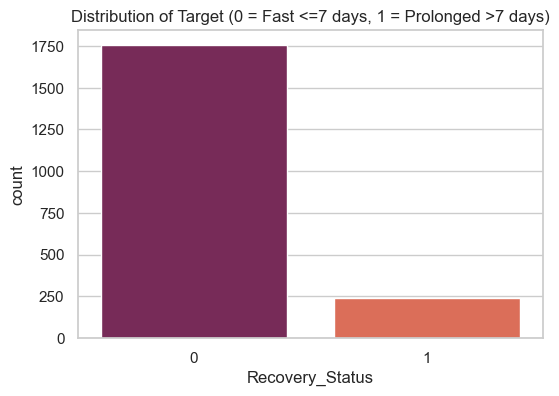

In [13]:
# First, drop missing target values before analysis
df = df.dropna(subset=['Recovery Time']).copy()

# Create Classification Target
df['Recovery_Status'] = (df['Recovery Time'] > 7).astype(int)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Recovery_Status', palette='rocket')
plt.title('Distribution of Target (0 = Fast <=7 days, 1 = Prolonged >7 days)')
plt.show()


#### ii. Relationship with features (scatter, violin, grouped bars)


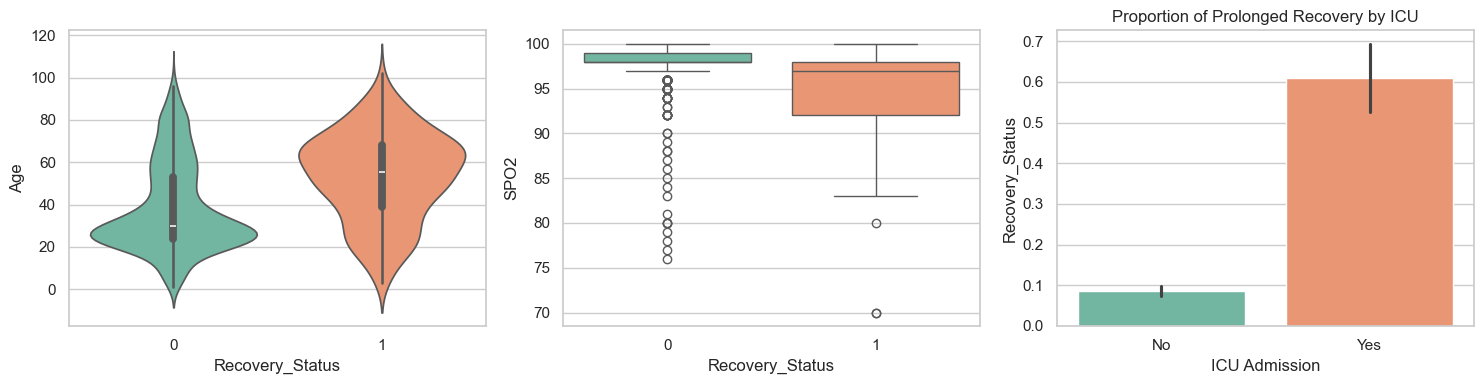

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.violinplot(data=df, x='Recovery_Status', y='Age', ax=axes[0], palette='Set2')
sns.boxplot(data=df, x='Recovery_Status', y='SPO2', ax=axes[1], palette='Set2')
sns.barplot(data=df, x='ICU Admission', y='Recovery_Status', ax=axes[2], palette='Set2')
axes[2].set_title("Proportion of Prolonged Recovery by ICU")
plt.tight_layout()
plt.show()


## 3. Data Cleaning


### a. missing values


#### i. missing values


In [15]:
print("Missing Values Before Imputation:")
print(df.isnull().sum())


Missing Values Before Imputation:
Age                 0
Sex                 0
Diagnosis           0
Systolic_BP         0
Diastolic_BP        0
SPO2                0
Body Temperature    0
ICU Admission       0
Recovery Time       0
Recovery_Status     0
dtype: int64


#### ii. Handling missing values (e.g., mean/median imputation, dropping rows)


In [16]:
num_features = ['Age', 'SPO2', 'Body Temperature', 'Systolic_BP', 'Diastolic_BP']
for col in num_features:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


#### iii. explain which method is used when handling missing values? Why your choices this method


- **Numerical Features:** Used **Median Imputation** because medical data (like age and blood pressure) often contains outliers, and the median is robust to extreme values compared to the mean.
- **Categorical Features:** Used **Mode Imputation** (most frequent) because categorical strings cannot be averaged, and taking the most common category is standard practice.


### b. Removing duplicates


#### i. Check Duplicates


In [17]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 23


#### ii. if found duplicates please Handling duplicates


In [18]:
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates have been dropped.")


Duplicates have been dropped.


### c. Fixing inconsistent data entries (e.g., formatting, spelling)


Already handled during EDA. Stripped whitespaces and used `.title()` to ensure 'MALE', 'Male', and 'male' all uniformly became 'Male'.


### d. Outlier detection and removal


#### i. check outlier variable and show using box plot


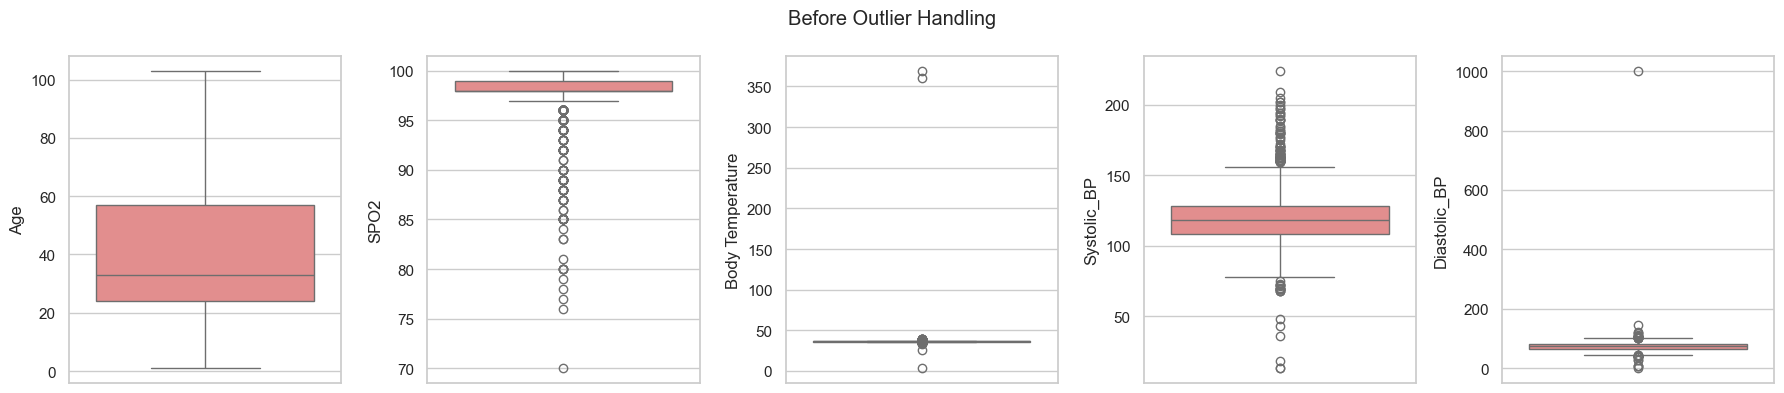

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(num_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightcoral')
plt.suptitle("Before Outlier Handling")
plt.tight_layout()
plt.show()


#### ii. Handling the outlier


In [20]:
# Applying IQR Capping
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)


#### iii. explain which method is used when handling outlier? Why you choose this method


I used the **IQR Capping (Winsorization)** method. I chose this method because dropping outliers completely would lose valuable clinical data. Capping brings extreme physiological anomalies back to the 1.5 IQR boundary without losing the patient row.


#### iv. check after handling outlier and show using box plot


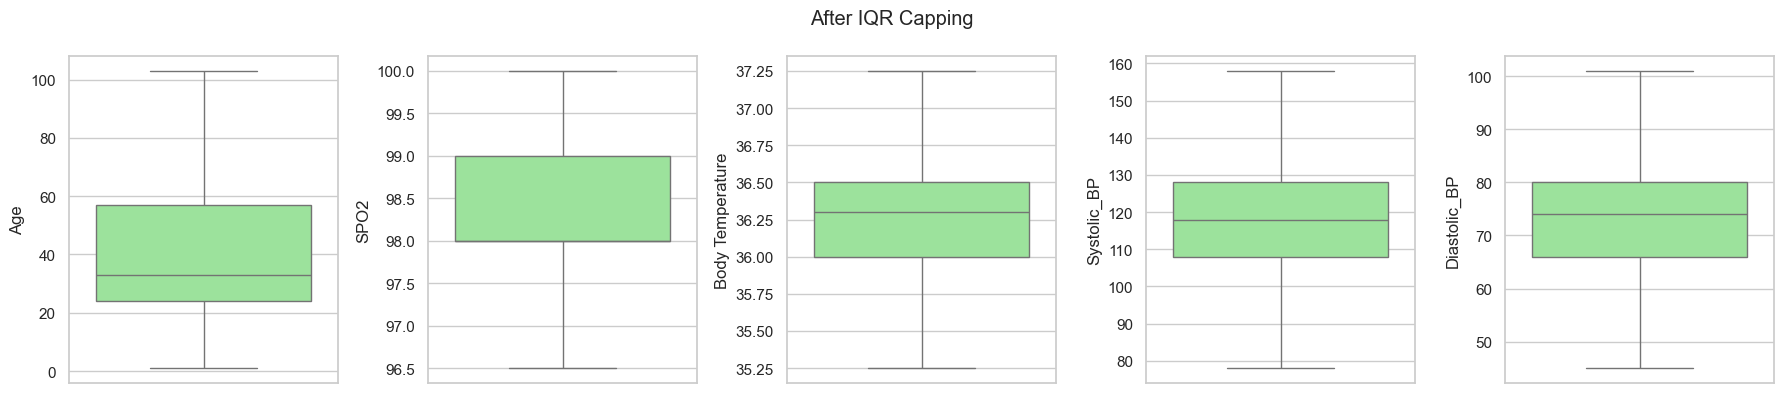

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(num_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightgreen')
plt.suptitle("After IQR Capping")
plt.tight_layout()
plt.show()


### e. Data Transformation


#### i. Normalization & ii. Standardization & iii. Log transformation & iv. Use your dataset if applicable. 1. Explain


**Method Chosen:** **Standardization (Z-score scaling)**.
**Explanation:** Since we transformed the skewed target into a Classification target (0 and 1), we don't need Log Transformation for the target. We use Standardization for the numerical features so they have a mean of 0 and std of 1. This helps models like Logistic Regression and algorithms that use distance metrics converge faster.


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_features] = scaler.fit_transform(df[num_features])
display(df_scaled[num_features].head())


,Age,SPO2,Body Temperature,Systolic_BP,Diastolic_BP
0,1.139618,0.852563,-0.835076,0.027556,-0.347796
1,-1.387915,0.852563,-0.835076,0.027556,0.558520
2,-1.250050,1.887164,-0.570824,-0.564636,-0.347796
3,-0.652633,-0.182037,0.486184,-0.090883,-0.619690
4,-1.525781,0.852563,-0.835076,-0.801513,0.105362


## 4. Feature Engineering


#### i. Creating new features (from existing ones)


In [23]:
df_scaled['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']
df_scaled['MAP'] = df['Diastolic_BP'] + (df['Systolic_BP'] - df['Diastolic_BP']) / 3.0
df_scaled['Age_Group'] = df['Age'].apply(lambda x: 'Child' if x < 18 else ('Adult' if x < 60 else 'Senior'))

df_scaled[['Pulse_Pressure', 'MAP']] = scaler.fit_transform(df_scaled[['Pulse_Pressure', 'MAP']])


#### ii. Date/time features extraction (e.g., day, month, weekday) & iii. Use if you need


Not applicable. The original dataset does not contain any Date or Time fields, and we have opted not to generate synthetic ones.


## 5. Feature Encoding


#### a. Label Encoding & b. One-Hot Encoding & c. Ordinal Encoding


In [24]:
from sklearn.preprocessing import LabelEncoder

# a. Label/Ordinal Encoding for Binary categories
df_scaled['Sex_Encoded'] = df_scaled['Sex'].map({'Male': 1, 'Female': 0})
df_scaled['ICU_Encoded'] = df_scaled['ICU Admission'].map({'Yes': 1, 'No': 0})

# c. Ordinal Encoding
df_scaled['Age_Group_Encoded'] = df_scaled['Age_Group'].map({'Child': 0, 'Adult': 1, 'Senior': 2})

# b. Label Encoding for Diagnosis (Indexing instead of One-Hot Encoding as requested)
le = LabelEncoder()
df_scaled['Diagnosis_Encoded'] = le.fit_transform(df_scaled['Diagnosis'])

# Creating a mapping dictionary so we know which index belongs to which diagnosis
diagnosis_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Diagnosis Encoding Mapping:")
print(diagnosis_mapping)


Diagnosis Encoding Mapping:
{'Cancer': np.int64(0), 'Cardiovascular Disease': np.int64(1), 'Diabetes': np.int64(2), 'Emergency Condition': np.int64(3), 'Gastrointestinal Disease': np.int64(4), 'Hypertension': np.int64(5), 'Infectious Disease': np.int64(6), 'Kidney Disease': np.int64(7), 'Neurological Disease': np.int64(8), 'Orthopedic Injury': np.int64(9), 'Other': np.int64(10), 'Pregnancy & Obstetrics': np.int64(11), 'Respiratory Disease': np.int64(12), 'Trauma': np.int64(13), 'Urinary Disease': np.int64(14)}


#### d. Explain which method your dataset is used, why you choose this method


- **Label Encoding (Mapping 1/0):** Used for `Sex` and `ICU Admission` because they are binary (only two possible values).
- **Ordinal Encoding:** Used for `Age_Group` because Child, Adult, Senior have a natural mathematical ordering (0 < 1 < 2).
- **Label Encoding (Indexing):** Used for `Diagnosis` to convert the ~20 diagnoses into a single numerical index column (0 to 19). This prevents the dataset from expanding into 20 extra columns (which happens with One-Hot Encoding) and keeps the data structure simple and directly mapped to the Excel file.


## 6. Feature selection


#### a. Use methods like i. Correlation matrix ii. Chi-square test


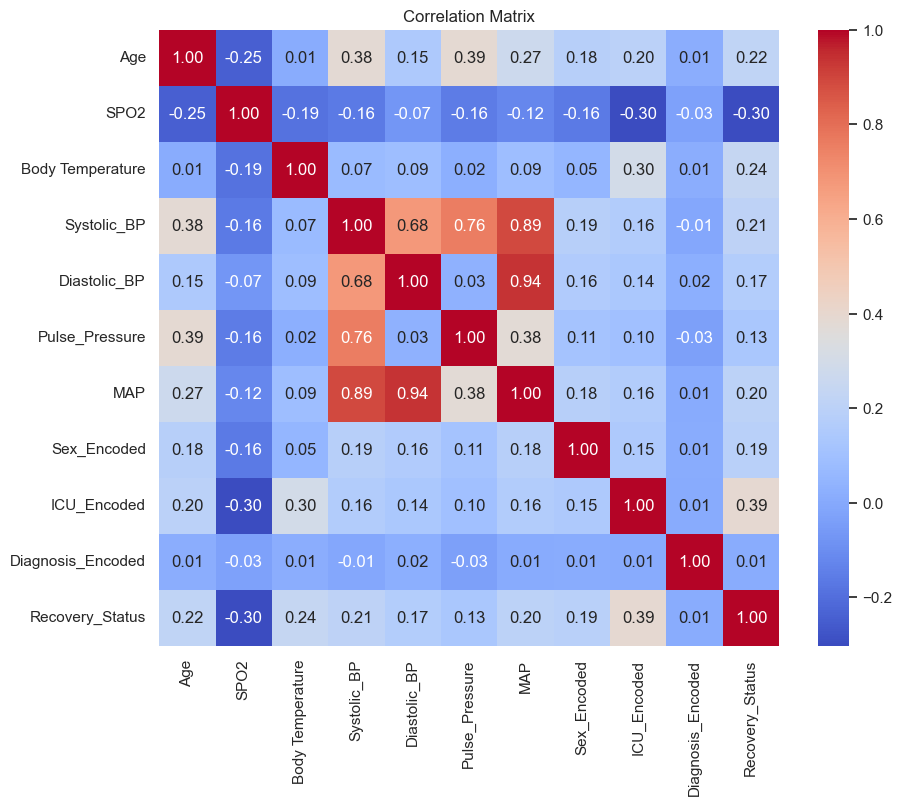

,Feature,Chi2 Score,P-Value
1,ICU_Encoded,285.877162,3.934660e-64
0,Sex_Encoded,46.655686,8.462110e-12
2,Age_Group_Encoded,13.081830,2.981740e-04
3,Diagnosis_Encoded,0.400788,5.266828e-01


In [25]:
# i. Correlation Matrix (Heatmap)
plt.figure(figsize=(10, 8))
corr_features = num_features + ['Pulse_Pressure', 'MAP', 'Sex_Encoded', 'ICU_Encoded', 'Diagnosis_Encoded', 'Recovery_Status']
sns.heatmap(df_scaled[corr_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ii. Chi-square test (for classification)
from sklearn.feature_selection import chi2
# Chi-square requires non-negative values, so we use categorical encoded columns
X_cat = df_scaled[['Sex_Encoded', 'ICU_Encoded', 'Age_Group_Encoded', 'Diagnosis_Encoded']]
y_target = df_scaled['Recovery_Status']

chi_scores, p_values = chi2(X_cat, y_target)
chi_df = pd.DataFrame({'Feature': X_cat.columns, 'Chi2 Score': chi_scores, 'P-Value': p_values})
display(chi_df.sort_values(by='Chi2 Score', ascending=False))


## 7. Constructing predictive features


In [26]:
final_features = num_features + ['Pulse_Pressure', 'MAP', 'Sex_Encoded', 'ICU_Encoded', 'Age_Group_Encoded', 'Diagnosis_Encoded']
X = df_scaled[final_features]
y = df_scaled['Recovery_Status']

print(f"Features Matrix X shape: {X.shape}")
print(f"Target Vector y shape: {y.shape}")


Features Matrix X shape: (1975, 11)
Target Vector y shape: (1975,)


## 8. Data Splitting


In [27]:
from sklearn.model_selection import train_test_split
# Using stratify=y to ensure both train and test have the same proportion of classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 1580 samples
Test set: 395 samples


## 9. Create a baseline method for benchmarking


In [28]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f"Baseline Accuracy (predicting majority class): {baseline_acc*100:.2f}%")
print("All our ML models must beat this accuracy to be considered useful.")


Baseline Accuracy (predicting majority class): 88.10%
All our ML models must beat this accuracy to be considered useful.


## 10. Train machine learning models (at least 5 models)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append({'Model': name, 'Accuracy': acc})

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
display(results_df)


,Model,Accuracy
2,Random Forest,0.926582
3,Gradient Boosting,0.916456
4,XGBoost,0.916456
0,Logistic Regression,0.911392
1,Decision Tree,0.875949


## 11. Perform hyperparameter tuning, and model selection


In [30]:
from sklearn.model_selection import RandomizedSearchCV

print("Tuning Random Forest Model...")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid, n_iter=10, cv=5, scoring='accuracy', random_state=42)
rf_search.fit(X_train, y_train)

best_model = rf_search.best_estimator_
print(f"Best Parameters: {rf_search.best_params_}")
print(f"Best CV Accuracy: {rf_search.best_score_*100:.2f}%")


Tuning Random Forest Model...
Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 20}
Best CV Accuracy: 91.90%


## 12. Select best model (s) and evaluate them


Final Test Accuracy: 92.15%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       348
           1       0.86      0.40      0.55        47

    accuracy                           0.92       395
   macro avg       0.89      0.70      0.75       395
weighted avg       0.92      0.92      0.91       395



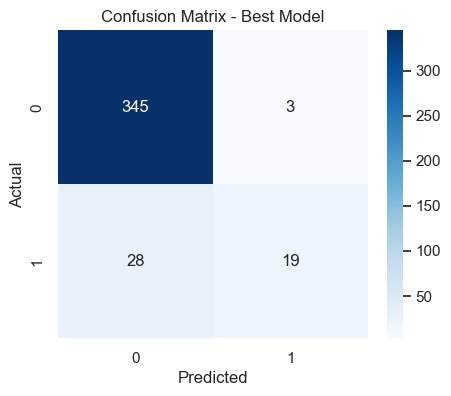

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_best = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred_best)

print(f"Final Test Accuracy: {final_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 13. Mitigate imbalanced class problem, if relevant


In [32]:
from imblearn.over_sampling import SMOTE

print("Original Class Distribution in Training Set:")
print(y_train.value_counts())

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass Distribution after SMOTE:")
print(y_train_sm.value_counts())

# Retrain the best model on the balanced dataset
best_model.fit(X_train_sm, y_train_sm)
y_pred_smote = best_model.predict(X_test)

print(f"\nAccuracy after SMOTE: {accuracy_score(y_test, y_pred_smote)*100:.2f}%")
print("Classification Report after SMOTE:")
print(classification_report(y_test, y_pred_smote))


Original Class Distribution in Training Set:
Recovery_Status
0    1394
1     186
Name: count, dtype: int64

Class Distribution after SMOTE:
Recovery_Status
0    1394
1    1394
Name: count, dtype: int64

Accuracy after SMOTE: 91.39%
Classification Report after SMOTE:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       348
           1       0.70      0.49      0.57        47

    accuracy                           0.91       395
   macro avg       0.82      0.73      0.76       395
weighted avg       0.91      0.91      0.91       395



In [33]:
# ========================================================
# TIJAABINTA BUKAAN CUSUB (LIVE PREDICTION DEMO) - SOO GAABTAY
# ========================================================
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Geli xogta bukaanka cusub (Bukaan 75 jir ah)
bukaanka_cusub = pd.DataFrame([{
    'Age': 75,
    'SPO2': 88,                   
    'Body Temperature': 39.5,     
    'Systolic_BP': 160,           
    'Diastolic_BP': 95,
    'Sex_Encoded': 1,             # 1 = Male, 0 = Female
    'ICU_Encoded': 1,             # 1 = Haa, 0 = Maya
    'Age_Group_Encoded': 2,       # 0=Child, 1=Adult, 2=Senior
    'Diagnosis_Encoded': 14       # 14 = Respiratory Disease (Ama lambar kale)
}])

# 2. Xisaabi Pulse Pressure iyo MAP
bukaanka_cusub['Pulse_Pressure'] = bukaanka_cusub['Systolic_BP'] - bukaanka_cusub['Diastolic_BP']
bukaanka_cusub['MAP'] = bukaanka_cusub['Diastolic_BP'] + (bukaanka_cusub['Systolic_BP'] - bukaanka_cusub['Diastolic_BP']) / 3.0

# 3. Samee Scaler cusub oo baranaya xogtii asalka ahayd
df_temp = df.copy()
df_temp['Pulse_Pressure'] = df_temp['Systolic_BP'] - df_temp['Diastolic_BP']
df_temp['MAP'] = df_temp['Diastolic_BP'] + (df_temp['Systolic_BP'] - df_temp['Diastolic_BP']) / 3.0
tiirarka_la_miisaamayo = ['Age', 'SPO2', 'Body Temperature', 'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure', 'MAP']

live_scaler = StandardScaler()
live_scaler.fit(df_temp[tiirarka_la_miisaamayo]) 
bukaanka_cusub[tiirarka_la_miisaamayo] = live_scaler.transform(bukaanka_cusub[tiirarka_la_miisaamayo])

# 4. Hubi in Tiirarku (Columns) ay u nidaamsan yihiin sidii X-tii asalka ahayd
bukaanka_cusub = bukaanka_cusub[X.columns]

# 5. Weydii Model-ka inuu Saadaaliyo (Predict)
natiijo = best_model.predict(bukaanka_cusub)

# 6. Soo saar Jawaabta Mishiinka (AI)
print("=== NATIIJADA SAADAALINTA AI-GA ===")
if natiijo[0] == 1:
    print("⚠️ DIGNIIN: Bukaankan wuxuu halis ugu jiraa Bogsasho Daahday (Prolonged Recovery > 7 days).")
else:
    print("✅ FARXAD: Bukaankan si degdeg ah ayuu u bogsanayaa (Fast Recovery <= 7 days).")


=== NATIIJADA SAADAALINTA AI-GA ===
⚠️ DIGNIIN: Bukaankan wuxuu halis ugu jiraa Bogsasho Daahday (Prolonged Recovery > 7 days).
